<a href="https://colab.research.google.com/github/SomayaRasoli/-leri-Derin-renme/blob/main/chapter04_classification_and_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [8]:
!pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 59.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.26.0 which is incompatible.


In [14]:
import os
os.environ["KERAS_BACKEND"] = "jax" # Matematiksel işlemleri yaparken JAX kütüphanesini kullan.

In [15]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic # %%backend.
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Classification and regression

### Classifying movie reviews: A binary classification example

#### The IMDb dataset

In [16]:
from keras.datasets import imdb # veri setinde 25.000 eğitim, 25.000 test olmak üzere

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
train_data[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [18]:
train_labels[0]

np.int64(1)

In [19]:
max([max(sequence) for sequence in train_data]) #modelinin "sözlük boyutunu" temsil eder.

9999

In [20]:
word_index = imdb.get_word_index() #(key)
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])#Sözlükte normalde kelimeyi verip sayıyı alırsın. bizim sayılar var ve kelimeleri istiyoruz. Bu yüzden sözlüğü tersine çeviriyoruz.
decoded_review = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[0]]#IMDB veri setinde ilk 3 sayı özel görevler için ayrılmıştır: 0: "Padding" (Boşluk doldurma),1: "Start of sequence" (Dizinin başlangıcı), 2: "Unknown" (Sözlükte olmayan kelime) Gerçek kelimeler ancak 3. indeksten sonra başlar. Bu yüzden her sayıyı 3 kaydırarak gerçek sözlük karşılığını buluruz.
# 10.000 kelimelik sınırın dışında kalan kelimeler (?) koyur,)
    )

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
decoded_review[:100]#"şifresi çözülmüş yorum"

"? this film was just brilliant casting location scenery story direction everyone's really suited the"

#### Preparing the data

In [22]:
import numpy as np

def multi_hot_encode(sequences, num_classes):
    results = np.zeros((len(sequences), num_classes)) # bomboş bir tablo (matris) oluşturuyoruz.
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.0 #
    return results

x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)

In [23]:
x_train[0] #en başındaki ilk satırı (yani ilk film yorumunu) ekrana getirir.

array([0., 1., 1., ..., 0., 0., 0.])

In [24]:
y_train = train_labels.astype("float32") #Hız: float32, standart float64'e göre yarı yarıya daha az yer kaplar ve ekran kartları.
y_test = test_labels.astype("float32")

#### Building your model

In [25]:
import keras
from keras import layers

model = keras.Sequential(
    [
                                              #Dense(16): 16 adet "nöron" (işlemci ünite) içeren bir katman demektir.10.000 tane kelime bilgisini alıp, onları daha küçük ve anlamlı 16 parçaya sıkıştırır.
        layers.Dense(16, activation="relu"),  #Sadece önemli olan sinyallerin bir sonraki katmana geçmesine izin verir (negatif değerleri sıfırlar).
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),#En son katmanda tek bir nöron vardır. Bu nöron, yorumun olumlu olma ihtimalini 0 ile 1 arasında bir sayı olarak verir.

    ]
)

In [26]:
model.compile(
    optimizer="adam", #(Antrenör)modelin hata yaptıkça kendi ağırlıklarını (bağlantılarını) nasıl düzelteceğini belirleyen algoritmadır.
    loss="binary_crossentropy", # (Hata Ölçer)
    metrics=["accuracy"], # (Başarı Karnesi)
)

#### Validating your approach

In [27]:
x_val = x_train[:10000] # Model 10.000  bakarak kendini geliştirmeyecek, sadece "Ne kadar iyi gidiyorum?" diye kendini test edecek.
partial_x_train = x_train[10000:] #(partial_x_train) 15.000 Yorum, görevi: Modelin ders çalışacağı sorular.
y_val = y_train[:10000] #Aynı bölme işlemini bu soruların "cevap anahtarları" (Olumlu/Olumsuz etiketleri) için de yapıyoruz.
partial_y_train = y_train[10000:] # (partial_y_train )15.000 Etiket (0/1), görevi: Modelin ders çalışacağı cevaplar.

In [28]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20, # Tekrar Sayısı
    batch_size=512, # Model, 15.000 yorumun hepsini tek seferde yutmaya çalışmaz. Bunun yerine veriyi 512'şerli küçük gruplar halinde okur.
    validation_data=(x_val, y_val), # Model her turun (epoch) sonunda, ders çalıştığı veriden bağımsız olan bu 10.000 yoruma bakar.
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.7795 - loss: 0.5328 - val_accuracy: 0.8620 - val_loss: 0.3792
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9055 - loss: 0.2822 - val_accuracy: 0.8864 - val_loss: 0.2924
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9354 - loss: 0.1929 - val_accuracy: 0.8877 - val_loss: 0.2795
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9542 - loss: 0.1434 - val_accuracy: 0.8853 - val_loss: 0.2856
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9689 - loss: 0.1106 - val_accuracy: 0.8832 - val_loss: 0.3029
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9775 - loss: 0.0866 - val_accuracy: 0.8814 - val_loss: 0.3211
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9855 - loss: 0.0665 - val_accuracy: 0.8804 - val_loss: 0.3476
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9909 - loss: 0.0515 - val_accuracy: 0.8772 - v

In [29]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2, # Otomatik Bölme
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9285 - loss: 0.2884 - val_accuracy: 0.9768 - val_loss: 0.0700
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9619 - loss: 0.1224 - val_accuracy: 0.9684 - val_loss: 0.0882
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9818 - loss: 0.0749 - val_accuracy: 0.9640 - val_loss: 0.0985
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9884 - loss: 0.0545 - val_accuracy: 0.9568 - val_loss: 0.1169
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9927 - loss: 0.0414 - val_accuracy: 0.9526 - val_loss: 0.1268
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9951 - loss: 0.0311 - val_accuracy: 0.9510 - val_loss: 0.1383
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9965 - loss: 0.0237 - val_accuracy: 0.9488 - val_loss: 0.1525
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9976 - loss: 0.0182 - val_accuracy: 0.9452 - v

In [30]:
history_dict = history.history #Modelin her bir eğitim turunda (epoch) hesapladığı değerleri birer liste halinde burada bulabilirsin.
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

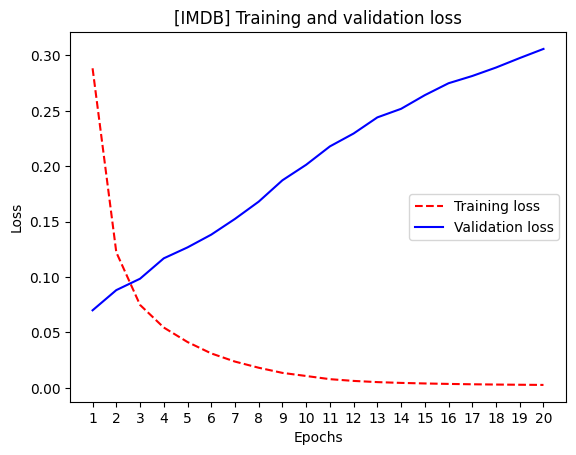

In [31]:
import matplotlib.pyplot as plt

history_dict = history.history #Model eğitilirken her turda (epoch) kaydedilen tüm verileri (hata payı, başarı oranı) bir sözlük yapısına aktarırız.
loss_values = history_dict["loss"] #Eğitim sırasında hem kendi çalıştığı sorulardaki hatayı (loss) hem de sınavdaki (doğrulama) hatasını (val_loss) listeler halinde çekeriz.
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1) # X ekseni için 1'den başlayıp kaç tur eğitim yapıldıysa o kadar sayı üretir (1, 2, 3... 20).
plt.plot(epochs, loss_values, "r--", label="Training loss") #Eğitim kaybını kırmızı ("r") ve kesikli çizgilerle ("--") çizer.
plt.plot(epochs, val_loss_values, "b", label="Validation loss") #Doğrulama kaybını mavi ("b") ve düz çizgiyle çizer.
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs) #X eksenindeki sayıların (1, 2, 3...) hepsinin tek tek görünmesini sağlar. Bu sayede hangi turda bozulma başladığını net görürüz.
plt.ylabel("Loss")
plt.legend()
plt.show()

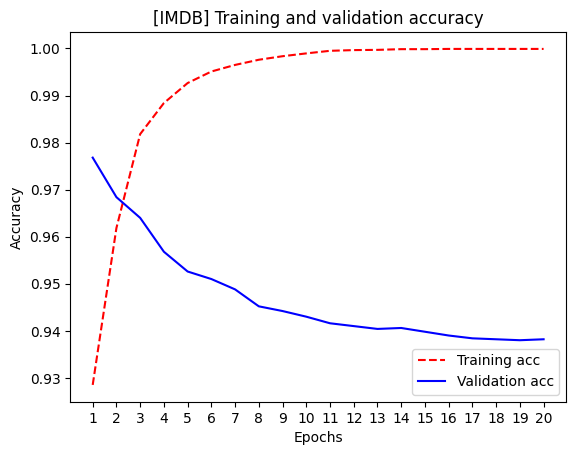

In [32]:
plt.clf() #Clear Figure
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc") # Eğitim başarısını kırmızı kesikli çizgilerle gösterir. Bu çizginin sürekli yükselip %100'e yaklaşması normaldir.
plt.plot(epochs, val_acc, "b", label="Validation acc") # Sınav başarısını mavi düz çizgiyle gösterir. Bizim asıl takip etmemiz gereken çizgi budur.
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs) #Alt taraftaki (X ekseni) tur sayılarını tek tek yazdırır (1, 2, 3... 20).
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [33]:
model = keras.Sequential( # Modeli sıfırdan oluşturuyoru.
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile( # Modelin nasıl öğreneceğini tekrar hatırlatıyoru.
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.fit(x_train, y_train, epochs=4, batch_size=512) # Model 4. turdan sonra ezberlemeye başlıyordu. Bu yüzden bu sefer modeli tam vaktinde, yani en başarılı olduğu noktada durduruyoru.
results = model.evaluate(x_test, y_test) # Modelin eğitimi bitti. Şimdi onu hayatında hiç görmediği 25.000 adet test yorumuyla (x_test) baş başa bırakıyoru.

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7768 - loss: 0.5171
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9071 - loss: 0.2586
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9359 - loss: 0.1823
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9509 - loss: 0.1424
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8782 - loss: 0.3199


In [35]:
results

[0.319929301738739, 0.8782399892807007]

#### Using a trained model to generate predictions on new data

In [36]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([[0.11643086],
       [0.99972636],
       [0.7665517 ],
       ...,
       [0.05941006],
       [0.0404807 ],
       [0.6533191 ]], dtype=float32)

#### Further experiments

#### Wrapping up

### Classifying newswires: A multiclass classification example

#### The Reuters dataset

In [40]:
from keras.datasets import reuters #Reuters haber veri setini içeri çağırıyoru.

(train_data, train_labels), (test_data, test_labels) = reuters.load_data( # reuters.load_data(num_words=10000) fonksiyon veriyi internetten indirir (veya bilgisayarındaysa yükler) ve iki parçaya böler.train_data & test_data: Haberlerin kendisidir.kelimele sayı dizileri(ID)olarak tutulur.train_labels & test_labels: Haberlerin hangi kategoriye ait olduğunu belirten sayılardır (etiketler).
    num_words=10000 #sadece en sık kullanılan 10.000 kelimeyi alıyoruz.
)

In [42]:
len(train_data) #, modelini eğitmek için elinde kaç tane haber metni olduğunu söyler.

reuters.load_data

<function keras.src.datasets.reuters.load_data(path='reuters.npz', num_words=None, skip_top=0, maxlen=None, test_split=0.2, seed=113, start_char=1, oov_char=2, index_from=3)>

In [43]:
len(test_data)

2246

In [44]:
train_data[10]

[1,
 245,
 273,
 207,
 156,
 53,
 74,
 160,
 26,
 14,
 46,
 296,
 26,
 39,
 74,
 2979,
 3554,
 14,
 46,
 4689,
 4329,
 86,
 61,
 3499,
 4795,
 14,
 61,
 451,
 4329,
 17,
 12]

In [46]:
word_index = reuters.get_word_index() #Reuters veri setindeki kelimelerin "sözlüğünü" indirir. Bu sözlükte kelimeler anahtar, sayılar ise değerdir.
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()]) #Elimizdeki sözlüğü tersine çevirir. Çünkü bizim elimizde sayılar var ve biz bu sayıların hangi kelimeye denk geldiğini bulmak istiyoruz.
decoded_newswire = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[10]] #train_data[10] (11. sıradaki haber) içindeki her bir sayıyı alır ve sözlükten karşılığını bulup boşluklarla birleştirir.
)

In [47]:
train_labels[10]

np.int64(3)

#### Preparing the data

In [48]:
x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)

In [50]:
def one_hot_encode(labels, num_classes=46): #modelin anlayamadığı "etiket numaralarını" (3, 5, 45 gibi), onun çok sevdiği "matris" formatına çeviriyor.
    results = np.zeros((len(labels), num_classes)) #Boş bir tablo oluşturur. Bu tabloda her haber için 46 tane kutucuk (sütun) vardır ve hepsi başlangıçta 0'dır.
    for i, label in enumerate(labels):
        results[i, label] = 1.0 #Sadece o haberin gerçek kategorisi hangi numaraysa, o numaralı kutucuğu 1 yapar.
    return results

y_train = one_hot_encode(train_labels)
y_test = one_hot_encode(test_labels)

In [51]:
from keras.utils import to_categorical

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

#### Building your model

In [56]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
        #IMDB'de sigmoid kullanmıştık çünkü tek bir ihtimal (evet/hayır) vardı. Softmax, çıkıştaki 46 nöronun ürettiği değerleri birer olasılığa dönüştürür. 46 olasılığın toplamının her zaman %100 (yani 1.0) olmasıdır.
    ]
)

In [55]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
        #Burada kullanılan 16 nöronluk iki katman, modelin "düşünme kapasitesini" temsil eder. İki seçenekli (IMDB) basit işler için 16 idealdir.Ama 46 seçenekli (Reuters) haberleri anlamak için bu katmanlar çok dar kalır (bilgi sığmaz).
    ]
)

In [57]:
top_3_accuracy = keras.metrics.TopKCategoricalAccuracy( # accuracy (doğruluk),
    k=3, name="top_3_accuracy"
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy", # çok sınıflı (46 kategori) sınıflandırmanın "standart hata ölçme" birimidir.
    metrics=["accuracy", top_3_accuracy],
)

#### Validating your approach

In [58]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

In [59]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - accuracy: 0.4173 - loss: 3.2284 - top_3_accuracy: 0.5759 - val_accuracy: 0.5620 - val_loss: 2.4580 - val_top_3_accuracy: 0.6390
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6149 - loss: 1.9201 - top_3_accuracy: 0.7035 - val_accuracy: 0.6470 - val_loss: 1.5729 - val_top_3_accuracy: 0.7420
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7121 - loss: 1.3075 - top_3_accuracy: 0.8066 - val_accuracy: 0.7150 - val_loss: 1.2522 - val_top_3_accuracy: 0.8160
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7828 - loss: 1.0018 - top_3_accuracy: 0.8691 - val_accuracy: 0.7620 - val_loss: 1.0984 - val_top_3_accuracy: 0.8520
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8294 - loss: 0.7882 - top_3_accuracy: 0.9114 - val_accuracy: 0.7850 - val_loss: 1.0016 - val_top_3_accuracy: 0.8800
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8696 - loss: 0.6161 - top_3_a

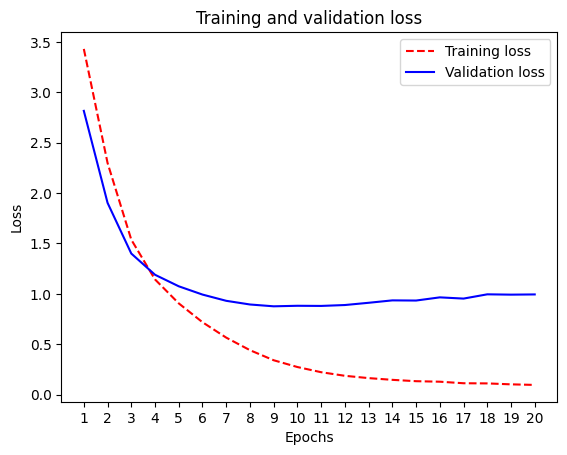

In [ ]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

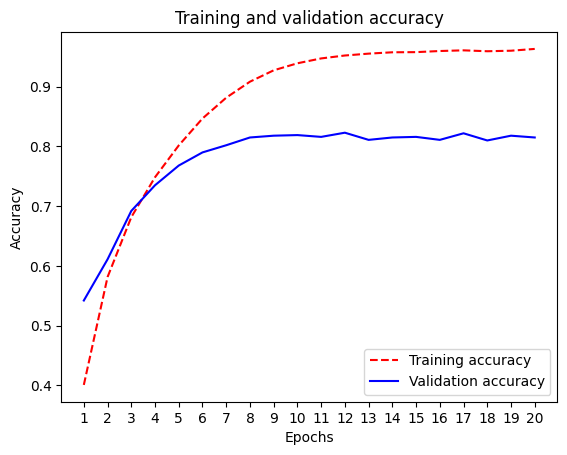

In [ ]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

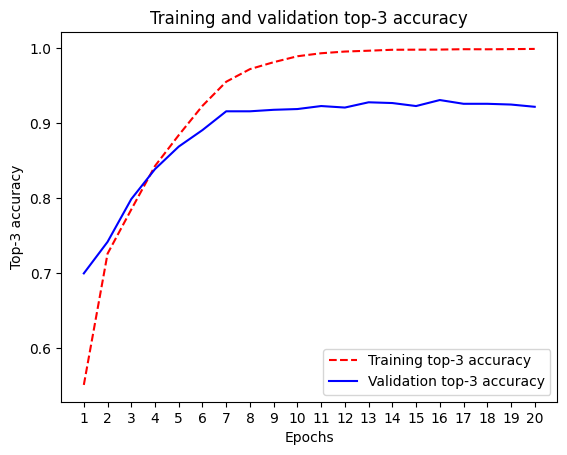

In [ ]:
plt.clf()
acc = history.history["top_3_accuracy"]
val_acc = history.history["val_top_3_accuracy"]
plt.plot(epochs, acc, "r--", label="Training top-3 accuracy")
plt.plot(epochs, val_acc, "b", label="Validation top-3 accuracy")
plt.title("Training and validation top-3 accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Top-3 accuracy")
plt.legend()
plt.show()

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    x_train,
    y_train,
    epochs=9,
    batch_size=512,
)
results = model.evaluate(x_test, y_test)

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 0.3635 - loss: 3.4798
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6004 - loss: 1.9694
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7096 - loss: 1.3192
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7658 - loss: 1.0413
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8293 - loss: 0.7948
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8679 - loss: 0.6301
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9038 - loss: 0.4775
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9237 - loss: 0.3819
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9405 - loss: 0.2774
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8073 - loss: 0.9086


In [ ]:
results

In [ ]:
import copy
test_labels_copy = copy.copy(test_labels)
np.random.shuffle(test_labels_copy)
hits_array = np.array(test_labels == test_labels_copy)
hits_array.mean()

np.float64(0.1981300089047195)

#### Generating predictions on new data

In [ ]:
predictions = model.predict(x_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [ ]:
predictions[0].shape

(46,)

In [ ]:
np.sum(predictions[0])

np.float32(1.0000001)

In [ ]:
np.argmax(predictions[0])

np.int64(3)

#### A different way to handle the labels and the loss

In [ ]:
y_train = train_labels
y_test = test_labels

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

#### The importance of having sufficiently large intermediate layers

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val),
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.0718 - loss: 3.7414 - val_accuracy: 0.0100 - val_loss: 3.1760
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2137 - loss: 2.7388 - val_accuracy: 0.6010 - val_loss: 1.6607
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6465 - loss: 1.4719 - val_accuracy: 0.6510 - val_loss: 1.4796
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7121 - loss: 1.1620 - val_accuracy: 0.6710 - val_loss: 1.4054
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7216 - loss: 1.0764 - val_accuracy: 0.6750 - val_loss: 1.3928
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7397 - loss: 0.9512 - val_accuracy: 0.6810 - val_loss: 1.3973
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7452 - loss: 0.8946 - val_accuracy: 0.6710 - val_loss: 1.4352
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7461 - loss: 0.8426 - val_accuracy: 0.6740 - val_loss

#### Further experiments

#### Wrapping up

### Predicting house prices: A regression example

#### The California Housing Price dataset

In [ ]:
from keras.datasets import california_housing

(train_data, train_targets), (test_data, test_targets) = (
    california_housing.load_data(version="small")
)

743530/743530 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


In [ ]:
train_data.shape

(480, 8)

In [ ]:
test_data.shape

(120, 8)

In [ ]:
train_targets

array([228400., 132900.,  60000.,  95200., 107000., 122500., 132000.,
       290100., 257800., 390100., 220800., 284900.,  97500., 415300.,
        84200., 185600., 216700., 233100., 127000., 182300.,  92300.,
        90700., 102100., 112500., 350700., 156500., 220700., 147400.,
       216700., 275000., 198200., 119100., 289500., 152500., 125000.,
       104500.,  93800.,  89300., 452600., 128600., 311500.,  90000.,
       218200., 131300.,  67500., 139400., 500001., 182600., 111300.,
       112500., 134700.,  71300., 207400., 331400., 107900.,  87500.,
       342200.,  87100., 314700., 368600., 211600., 338900., 366100.,
       164300.,  91700., 261400., 218500., 155400., 273700.,  81800.,
       138800.,  99700., 156300., 140600., 152700., 108900., 351200.,
       126000., 137500., 196900., 240000., 172800., 254200.,  97500.,
       182700., 162500.,  86100., 226700., 412500., 165900., 327100.,
       162500., 188800., 183800.,  90600., 372000., 275000., 151800.,
       125000., 1291

#### Preparing the data

In [ ]:
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)
x_train = (train_data - mean) / std
x_test = (test_data - mean) / std

In [ ]:
y_train = train_targets / 100000
y_test = test_targets / 100000

#### Building your model

In [ ]:
def get_model():
    model = keras.Sequential(
        [
            layers.Dense(64, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(1),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mean_absolute_error"],
    )
    return model

#### Validating your approach using K-fold validation

In [ ]:
k = 4
num_val_samples = len(x_train) // k
num_epochs = 50
all_scores = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    model.fit(
        fold_x_train,
        fold_y_train,
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    scores = model.evaluate(fold_x_val, fold_y_val, verbose=0)
    val_loss, val_mae = scores
    all_scores.append(val_mae)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [ ]:
[round(value, 3) for value in all_scores]

[0.294, 0.275, 0.275, 0.313]

In [ ]:
round(np.mean(all_scores), 3)

np.float64(0.289)

In [ ]:
k = 4
num_val_samples = len(x_train) // k
num_epochs = 200
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    history = model.fit(
        fold_x_train,
        fold_y_train,
        validation_data=(fold_x_val, fold_y_val),
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    mae_history = history.history["val_mean_absolute_error"]
    all_mae_histories.append(mae_history)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [ ]:
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)
]

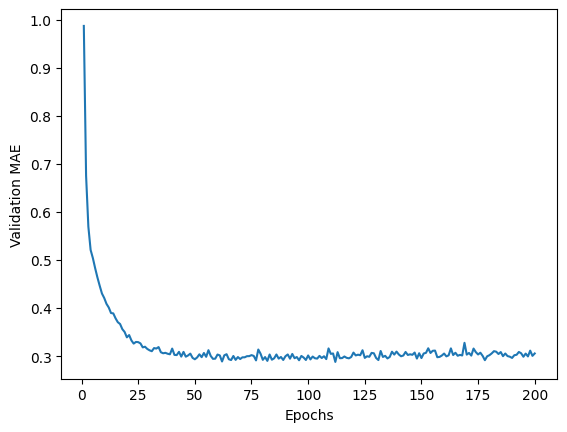

In [ ]:
epochs = range(1, len(average_mae_history) + 1)
plt.plot(epochs, average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

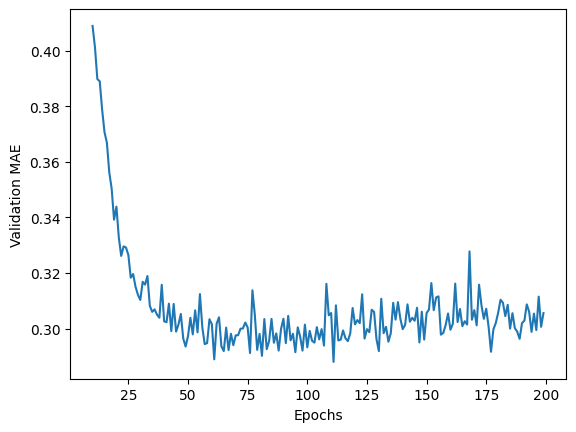

In [ ]:
truncated_mae_history = average_mae_history[10:]
epochs = range(10, len(truncated_mae_history) + 10)
plt.plot(epochs, truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

In [ ]:
model = get_model()
model.fit(x_train, y_train, epochs=130, batch_size=16, verbose=0)
test_mean_squared_error, test_mean_absolute_error = model.evaluate(
    x_test, y_test
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.3094 - mean_absolute_error: 0.3225


In [ ]:
round(test_mean_absolute_error, 3)

0.306

#### Generating predictions on new data

In [ ]:
predictions = model.predict(x_test)
predictions[0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


array([2.659489], dtype=float32)

#### Wrapping up